# Modelagem UAVIDS-2025: Detecção de Intrusão em Redes UAV

Este notebook cobre as fases **Data Preparation**, **Modeling** e **Evaluation** do ciclo CRISP-DM:

1. Pipeline sklearn com ColumnTransformer
2. Comparativo de 3 modelos no MLflow Tracking com CV 5-fold
3. Tuning do vencedor com RandomizedSearchCV
4. Avaliação final com métricas por classe e matriz de confusão
5. Model Registry com alias `@production`

In [21]:
# ============================================================
# CONFIGURACAO MLFLOW
# ============================================================
import mlflow
from pathlib import Path

# Garante que mlruns/ existe na raiz do projeto (cwd do VS Code)
Path('mlruns').mkdir(exist_ok=True)

# URI absoluta cross-platform (evita problemas com file:./mlruns no Windows)
_mlruns_uri = Path('mlruns').resolve().as_uri()
mlflow.set_tracking_uri(_mlruns_uri)
mlflow.set_experiment('uavids2025_ids')

print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print('Experimento:  uavids2025_ids')

Tracking URI: file:///C:/Users/User/Documents/datasci/notebooks/mlruns
Experimento:  uavids2025_ids


In [22]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import FunctionTransformer

import xgboost as xgb
import lightgbm as lgb
import mlflow
from mlflow.tracking import MlflowClient

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATASET_PATH = 'data/raw/UAVIDS-2025.csv'
EXPERIMENT_NAME = 'uavids2025_ids'
MODEL_NAME = 'previsor_uav_ids'

# Paleta semantica consistente com EDA
PALETTE = {
    'Normal Traffic':   '#2196F3',
    'Blackhole Attack': '#F44336',
    'Flooding Attack':  '#FF9800',
    'Sybil Attack':     '#9C27B0',
    'Wormhole Attack':  '#E91E63',
}
CLASSES_ORDER = list(PALETTE.keys())

print('Setup concluido.')
print(f'XGBoost version:  {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')
print(f'MLflow version:   {mlflow.__version__}')

Setup concluido.
XGBoost version:  2.0.3
LightGBM version: 4.6.0
MLflow version:   3.12.0


## 1. Carregamento e Preparação dos Dados

In [23]:
df = pd.read_csv(DATASET_PATH)

# --- Feature engineering---
eps_small = 1e-9
eps_hop   = 1.0

df['loss_ratio']         = df['LostPackets']     / (df['TxPackets']        + eps_small)
df['tx_efficiency']      = df['RxBytes']          / (df['TxBytes']          + eps_small)
df['throughput_per_hop'] = df['Throughput/Kbps']  / (df['AverageHopCount']  + eps_hop)

# --- Definição de features ---
FEATURES = [
    # Connection
    'FlowDuration/s', 'SrcPort', 'DstPort',
    # Traffic Volume
    'TxPackets', 'RxPackets', 'LostPackets',
    'TxBytes', 'RxBytes',
    'TxPacketRate/s', 'RxPacketRate/s',
    'TxByteRate/s', 'RxByteRate/s',
    'MeanPacketSize',
    # Performance
    'MeanDelay/s', 'MeanJitter/s',
    'Throughput/Kbps', 'PacketDropRate', 'AverageHopCount',
    # Derivadas (EDA)
    'loss_ratio', 'tx_efficiency', 'throughput_per_hop',
]

TARGET = 'label'

X = df[FEATURES]
y = df[TARGET]

print(f'Shape X: {X.shape}')
print(f'Classes: {y.nunique()} -> {sorted(y.unique())}')
print(f'\nDistribuição do alvo:')
print(y.value_counts().to_string())

Shape X: (122171, 21)
Classes: 5 -> ['Blackhole Attack', 'Flooding Attack', 'Normal Traffic', 'Sybil Attack', 'Wormhole Attack']

Distribuição do alvo:
label
Normal Traffic      26172
Blackhole Attack    26110
Wormhole Attack     26086
Sybil Attack        24077
Flooding Attack     19726


## 2. Split Estratificado Treino / Teste

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Treino: {X_train.shape[0]:,} amostras')
print(f'Teste:  {X_test.shape[0]:,} amostras')
print()
print('Distribuição treino (%):')
print((y_train.value_counts(normalize=True) * 100).round(1).to_string())
print()
print('Distribuição teste (%):')
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())

Treino: 97,736 amostras
Teste:  24,435 amostras

Distribuição treino (%):
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1

Distribuição teste (%):
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1


## 3. Pipeline sklearn

In [25]:
def clip_packet_drop_rate(X):
    """Clip PacketDropRate para [0, 1]. 81 registros têm valor > 1 (artefato NS-3)."""
    X = X.copy()
    if hasattr(X, 'columns') and 'PacketDropRate' in X.columns:
        idx = list(X.columns).index('PacketDropRate')
        X.iloc[:, idx] = X.iloc[:, idx].clip(0, 1)
    elif hasattr(X, 'shape'):
        # numpy array - PacketDropRate é a coluna 16 (0-indexed) na lista FEATURES
        pdr_idx = FEATURES.index('PacketDropRate')
        X[:, pdr_idx] = np.clip(X[:, pdr_idx], 0, 1)
    return X


def construir_preprocessador():
    """Retorna um ColumnTransformer com imputer + scaler para todas as features."""
    transformador = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
            ]), FEATURES),
        ],
        remainder='drop'
    )
    return transformador


def construir_pipeline(classificador):
    """Monta o Pipeline completo: clip -> preprocessador -> classificador."""
    return Pipeline([
        ('clip',  FunctionTransformer(clip_packet_drop_rate, validate=False)),
        ('prep',  construir_preprocessador()),
        ('clf',   classificador),
    ])


# Verificar que o pipeline constrói sem erro
pipe_teste = construir_pipeline(LogisticRegression(max_iter=100))
print('Pipeline construído com sucesso.')
print(pipe_teste)

Pipeline construído com sucesso.
Pipeline(steps=[('clip',
                 FunctionTransformer(func=<function clip_packet_drop_rate at 0x000001AE98E1AC00>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['FlowDuration/s', 'SrcPort',
                                                   'DstPort', 'TxPackets',
                                                   'RxPackets', 'LostPackets',
                                                   'TxBytes', 'RxBytes',
                                                   'TxPacketRate/s',
                                       

## 4. Validação Cruzada

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Definicao dos 4 modelos (com regularizacao para mitigar overfitting) ---
MODELOS = {
    'LogisticRegression': LogisticRegression(
        C=0.5,                          # L2 mais forte (default e C=1.0)
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial',
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,                   # limita profundidade (antes ilimitada)
        min_samples_leaf=20,            # folhas exigem mais amostras
        min_samples_split=40,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150,               # poucas arvores (regularizacao sem early stop)
        learning_rate=0.05,             # aprendizado mais lento
        max_depth=3,                    # arvores rasas (antes 6)
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,                  # regularizacao L1
        reg_lambda=3.0,                 # regularizacao L2
        min_child_weight=10,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        num_leaves=8,                   # consistente com max_depth=3 (2^3)
        subsample=0.8,
        subsample_freq=1,               # ativa o subsample (sem isso e ignorado)
        colsample_bytree=0.8,
        reg_alpha=1.0,                  # lambda_l1
        reg_lambda=3.0,                 # lambda_l2
        min_child_samples=50,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

print('\nModelos configurados (com regularizacao anti-overfitting):')
for nome in MODELOS:
    print(f'  - {nome}')


Modelos configurados (com regularizacao anti-overfitting):
  - LogisticRegression
  - RandomForest
  - XGBoost
  - LightGBM


**Função:** Treinar e comparar os 3 modelos com validação cruzada, registrando cada run no MLflow Tracking.

**Método:** `cross_validate()` com `StratifiedKFold(n_splits=5)` a estratificação garante que cada fold preserve a proporção das classes (especialmente Flooding com 16%). O pipeline completo (clip -> scaler -> classificador) é ajustado nos folds de treino e avaliado no fold de validação, sem qualquer contato com o conjunto de teste holdout. Métricas e o pipeline serializado são logados no MLflow via `log_param`, `log_metric` e `log_model`.

In [27]:
resultados_cv = {}

# XGBoost precisa de labels numericas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f'Classes codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print()

# Pre-processamento do primeiro fold para curvas de aprendizado por round
fold_idxs = list(skf.split(X_train, y_train_enc))
lc_tr_idx, lc_val_idx = fold_idxs[0]
X_lc_tr  = X_train.iloc[lc_tr_idx]
X_lc_val = X_train.iloc[lc_val_idx]
y_lc_tr_enc  = y_train_enc[lc_tr_idx]
y_lc_val_enc = y_train_enc[lc_val_idx]
y_lc_tr_str  = y_train.iloc[lc_tr_idx]
y_lc_val_str = y_train.iloc[lc_val_idx]
prep_lc = construir_preprocessador()
X_lc_tr_prep  = prep_lc.fit_transform(clip_packet_drop_rate(X_lc_tr))
X_lc_val_prep = prep_lc.transform(clip_packet_drop_rate(X_lc_val))

for nome, clf in MODELOS.items():
    print(f'Treinando {nome}...')

    y_cv = y_train_enc if nome == 'XGBoost' else y_train

    pipe = construir_pipeline(clf)

    cv_results = cross_validate(
        pipe, X_train, y_cv,
        cv=skf,
        scoring={
            'f1_macro': 'f1_macro',
            'accuracy': 'accuracy',
        },
        return_train_score=True,
        n_jobs=1,
    )

    f1_mean       = cv_results['test_f1_macro'].mean()
    f1_std        = cv_results['test_f1_macro'].std()
    acc_mean      = cv_results['test_accuracy'].mean()
    acc_std       = cv_results['test_accuracy'].std()
    train_f1_mean = cv_results['train_f1_macro'].mean()
    train_f1_std  = cv_results['train_f1_macro'].std()
    gap_f1        = train_f1_mean - f1_mean

    resultados_cv[nome] = {
        'f1_macro_mean':       f1_mean,
        'f1_macro_std':        f1_std,
        'accuracy_mean':       acc_mean,
        'accuracy_std':        acc_std,
        'train_f1_macro_mean': train_f1_mean,
        'train_f1_macro_std':  train_f1_std,
        'gap_f1_macro':        gap_f1,
        'f1_folds':            cv_results['test_f1_macro'],
        'train_f1_folds':      cv_results['train_f1_macro'],
        'fit_time_mean':       cv_results['fit_time'].mean(),
        'pipe':                pipe,
        'y_cv':                y_cv,
    }

    with mlflow.start_run(run_name=nome):
        params = clf.get_params()
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param('cv_folds', 5)
        mlflow.log_param('features_count', len(FEATURES))
        mlflow.log_param('class_balance_strategy', 'class_weight=balanced')

        mlflow.log_metric('f1_macro_cv_mean',       f1_mean)
        mlflow.log_metric('f1_macro_cv_std',        f1_std)
        mlflow.log_metric('accuracy_cv_mean',       acc_mean)
        mlflow.log_metric('accuracy_cv_std',        acc_std)
        mlflow.log_metric('fit_time_mean_s',        cv_results['fit_time'].mean())
        mlflow.log_metric('train_f1_macro_cv_mean', train_f1_mean)
        mlflow.log_metric('train_f1_macro_cv_std',  train_f1_std)
        mlflow.log_metric('gap_f1_macro',           gap_f1)

        for i, (tr, val) in enumerate(zip(cv_results['train_f1_macro'], cv_results['test_f1_macro'])):
            mlflow.log_metric('train_f1_macro_fold', tr,  step=i)
            mlflow.log_metric('val_f1_macro_fold',   val, step=i)

        folds = np.arange(1, 6)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(folds, cv_results['train_f1_macro'], 'o-',  color='#2196F3', label='Treino')
        ax.plot(folds, cv_results['test_f1_macro'],  's--', color='#F44336', label='Validacao')
        ax.fill_between(
            folds,
            cv_results['train_f1_macro'],
            cv_results['test_f1_macro'],
            alpha=0.15, color='#FF9800', label=f'Gap medio: {gap_f1:.4f}',
        )
        ax.set_xlabel('Fold')
        ax.set_ylabel('F1-macro')
        ax.set_title(f'Train vs. Validacao por Fold - {nome}', fontweight='bold')
        ax.legend()
        ax.set_ylim(
            max(0, min(cv_results['test_f1_macro'].min(), cv_results['train_f1_macro'].min()) - 0.02),
            1.01,
        )
        plt.tight_layout()
        mlflow.log_figure(fig, f'overfitting_{nome}.png')
        plt.close(fig)

        if nome in ('XGBoost', 'LightGBM'):
            clf_lc = clf.__class__(**clf.get_params())
            if nome == 'XGBoost':
                clf_lc.fit(
                    X_lc_tr_prep, y_lc_tr_enc,
                    eval_set=[(X_lc_tr_prep, y_lc_tr_enc), (X_lc_val_prep, y_lc_val_enc)],
                    verbose=False,
                )
                evals      = clf_lc.evals_result()
                train_loss = evals['validation_0']['mlogloss']
                val_loss   = evals['validation_1']['mlogloss']
                metric_nm  = 'mlogloss'
            else:
                evals_res = {}
                clf_lc.fit(
                    X_lc_tr_prep, y_lc_tr_str,
                    eval_set=[(X_lc_tr_prep, y_lc_tr_str), (X_lc_val_prep, y_lc_val_str)],
                    callbacks=[lgb.record_evaluation(evals_res)],
                )
                keys_lc    = list(evals_res.keys())
                metric_nm  = list(evals_res[keys_lc[0]].keys())[0]
                train_loss = evals_res[keys_lc[0]][metric_nm]
                val_loss   = evals_res[keys_lc[1]][metric_nm]

            for i, (tr, val) in enumerate(zip(train_loss, val_loss)):
                mlflow.log_metric(f'train_{metric_nm}', tr,  step=i)
                mlflow.log_metric(f'val_{metric_nm}',   val, step=i)
            best_round = int(val_loss.index(min(val_loss))) + 1
            mlflow.log_metric('best_round_early_stop', best_round)

            rounds = range(1, len(train_loss) + 1)
            fig_lc, ax_lc = plt.subplots(figsize=(9, 4))
            ax_lc.plot(rounds, train_loss, color='#2196F3', linewidth=1.2, label='Treino')
            ax_lc.plot(rounds, val_loss,   color='#F44336', linewidth=1.2, label='Validacao')
            ax_lc.axvline(best_round, color='#4CAF50', linestyle='--', linewidth=1.2,
                          label=f'Melhor round: {best_round}')
            ax_lc.set_xlabel('Boosting Round')
            ax_lc.set_ylabel(metric_nm)
            ax_lc.set_title(f'Curva de Aprendizado por Round - {nome}', fontweight='bold')
            ax_lc.legend()
            plt.tight_layout()
            mlflow.log_figure(fig_lc, 'learning_curve_by_round.png')
            plt.close(fig_lc)

        pipe_para_log = construir_pipeline(clf)
        pipe_para_log.fit(X_train, y_cv)
        mlflow.sklearn.log_model(pipe_para_log, name='model')

    print(f'  Train F1-macro: {train_f1_mean:.4f} +/- {train_f1_std:.4f}')
    print(f'  Val   F1-macro: {f1_mean:.4f} +/- {f1_std:.4f}  |  Gap: {gap_f1:.4f}')
    print(f'  Accuracy CV:    {acc_mean:.4f} +/- {acc_std:.4f}')
    print(f'  Fit time medio: {cv_results["fit_time"].mean():.1f}s')
    print()


Classes codificadas: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}

Treinando LogisticRegression...


2026/05/29 20:51:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.8177 +/- 0.0004
  Val   F1-macro: 0.8180 +/- 0.0026  |  Gap: -0.0003
  Accuracy CV:    0.8153 +/- 0.0027
  Fit time medio: 3.8s

Treinando RandomForest...


2026/05/29 20:52:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.9464 +/- 0.0005
  Val   F1-macro: 0.9437 +/- 0.0015  |  Gap: 0.0027
  Accuracy CV:    0.9420 +/- 0.0014
  Fit time medio: 5.7s

Treinando XGBoost...


2026/05/29 20:52:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.9337 +/- 0.0006
  Val   F1-macro: 0.9324 +/- 0.0022  |  Gap: 0.0013
  Accuracy CV:    0.9315 +/- 0.0022
  Fit time medio: 1.9s

Treinando LightGBM...


2026/05/29 20:52:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.9397 +/- 0.0008
  Val   F1-macro: 0.9381 +/- 0.0017  |  Gap: 0.0016
  Accuracy CV:    0.9370 +/- 0.0017
  Fit time medio: 1.2s



## 5. Comparativo dos Modelos

In [28]:
# Tabela comparativa — Experimento principal (5 classes)
tabela = pd.DataFrame([
    {
        'Modelo':          nome,
        'F1-val (media)':  f'{v["f1_macro_mean"]:.4f}',
        'F1-val (std)':    f'{v["f1_macro_std"]:.4f}',
        'F1-treino':       f'{v["train_f1_macro_mean"]:.4f}',
        'Gap':             f'{v["gap_f1_macro"]:.4f}',
        'Accuracy':        f'{v["accuracy_mean"]:.4f}',
        'Fit time (s)':    f'{v["fit_time_mean"]:.1f}',
    }
    for nome, v in resultados_cv.items()
])

print('=' * 85)
print('COMPARATIVO DE MODELOS — CV 5-fold | Experimento: uavids2025_ids (5 classes)')
print('=' * 85)
print(tabela.to_string(index=False))
print('=' * 85)

vencedor_nome = max(resultados_cv, key=lambda n: resultados_cv[n]['f1_macro_mean'])
vencedor_f1   = resultados_cv[vencedor_nome]['f1_macro_mean']
vencedor_std  = resultados_cv[vencedor_nome]['f1_macro_std']
print(f'\nVencedor: {vencedor_nome}  (F1-macro = {vencedor_f1:.4f} +/- {vencedor_std:.4f})')


COMPARATIVO DE MODELOS — CV 5-fold | Experimento: uavids2025_ids (5 classes)
            Modelo F1-val (media) F1-val (std) F1-treino     Gap Accuracy Fit time (s)
LogisticRegression         0.8180       0.0026    0.8177 -0.0003   0.8153          3.8
      RandomForest         0.9437       0.0015    0.9464  0.0027   0.9420          5.7
           XGBoost         0.9324       0.0022    0.9337  0.0013   0.9315          1.9
          LightGBM         0.9381       0.0017    0.9397  0.0016   0.9370          1.2

Vencedor: RandomForest  (F1-macro = 0.9437 +/- 0.0015)


**Função:** Visualizar o comparativo de F1-macro dos 3 modelos destacando o vencedor.

**Método:** Gráfico de barras com barras de erro (`yerr=std`) usando `ax.bar()`. As barras de erro mostram o desvio padrão entre os 5 folds um modelo com F1 alto mas desvio alto pode ser menos confiável que outro ligeiramente inferior mas mais estável.

In [29]:
nomes     = list(resultados_cv.keys())
f1s       = [resultados_cv[n]['f1_macro_mean']       for n in nomes]
train_f1s = [resultados_cv[n]['train_f1_macro_mean'] for n in nomes]
stds      = [resultados_cv[n]['f1_macro_std']         for n in nomes]
gaps      = [resultados_cv[n]['gap_f1_macro']         for n in nomes]
cores     = ['#4CAF50' if n == vencedor_nome else '#90A4AE' for n in nomes]

with mlflow.start_run(run_name='comparativo_modelos'):
    # --- Barras: F1-macro validação ---
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(nomes, f1s, yerr=stds, capsize=6,
                  color=cores, alpha=0.88, edgecolor='white', linewidth=1.2,
                  error_kw={'linewidth': 1.5, 'ecolor': '#333'})
    for bar, f1, std in zip(bars, f1s, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f'{f1:.4f}\n±{std:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
        )
    ax.set_ylabel('F1-macro (CV 5-fold)', fontsize=11)
    ax.set_title('Comparativo de Modelos - UAVIDS-2025\nVerde = vencedor', fontsize=12, fontweight='bold')
    ax.set_ylim(min(f1s) - 0.05, 1.02)
    plt.tight_layout()
    mlflow.log_figure(fig, 'comparativo_modelos_barras.png')
    plt.close(fig)

    # --- Boxplot dos folds ---
    fig, ax = plt.subplots(figsize=(7, 5))
    fold_data = [resultados_cv[n]['f1_folds'] for n in nomes]
    bp = ax.boxplot(fold_data, labels=nomes, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    ax.set_ylabel('F1-macro por fold', fontsize=11)
    ax.set_title('Distribuição do F1-macro nos 5 Folds', fontsize=12, fontweight='bold')
    plt.tight_layout()
    mlflow.log_figure(fig, 'comparativo_modelos_boxplot.png')
    plt.close(fig)

    # --- Train vs. Validação agrupado (diagnóstico de overfitting) ---
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(nomes))
    w = 0.35
    ax.bar(x - w/2, train_f1s, w, label='Treino',    color='#2196F3', alpha=0.85)
    ax.bar(x + w/2, f1s,       w, label='Validação', color='#F44336', alpha=0.85)
    for i, (tr, val, gap) in enumerate(zip(train_f1s, f1s, gaps)):
        ax.text(i, max(tr, val) + 0.005, f'gap={gap:.4f}', ha='center', fontsize=9, color='#333')
    ax.set_xticks(x)
    ax.set_xticklabels(nomes)
    ax.set_ylabel('F1-macro (média CV 5-fold)', fontsize=11)
    ax.set_title('Train vs. Validação - Diagnóstico de Overfitting', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylim(min(f1s + train_f1s) - 0.05, 1.04)
    plt.tight_layout()
    mlflow.log_figure(fig, 'overfitting_gap_comparativo.png')
    plt.close(fig)

    # Métricas de resumo da comparação
    for nome in nomes:
        mlflow.log_metric(f'{nome}_f1_val',   resultados_cv[nome]['f1_macro_mean'])
        mlflow.log_metric(f'{nome}_f1_train', resultados_cv[nome]['train_f1_macro_mean'])
        mlflow.log_metric(f'{nome}_gap',      resultados_cv[nome]['gap_f1_macro'])

print('Gráficos logados no MLflow (run: comparativo_modelos):')
print('  - comparativo_modelos_barras.png')
print('  - comparativo_modelos_boxplot.png')
print('  - overfitting_gap_comparativo.png')

Gráficos logados no MLflow (run: comparativo_modelos):
  - comparativo_modelos_barras.png
  - comparativo_modelos_boxplot.png
  - overfitting_gap_comparativo.png


O que o comparativo de modelos mostra (CV 5-fold, 5 classes):

- LogisticRegression: 0,8180. Continua bem abaixo dos demais, cerca de 12 pontos percentuais. O modelo linear nao captura a fronteira nao-linear entre Blackhole e Wormhole.
- RandomForest: 0,9437. E o vencedor e tem o menor gap treino-validacao entre os modelos fortes (0,0027). A regularizacao (profundidade limitada, folhas com mais amostras) deixou o RF estavel sem perder desempenho.
- XGBoost: 0,9324 e LightGBM: 0,9381. Ficaram logo abaixo do RF apos a regularizacao, mas com gaps minusculos (0,0013 e 0,0016).
- As barras de erro sao pequenas nos quatro modelos, o que indica scores consistentes entre os folds. O ranking nao e fruto de variacao aleatoria.
- Decisao: o RandomForest segue para o tuning de hiperparametros.

**Função:** Analisar a distribuição dos scores nos 5 folds para avaliar estabilidade além do valor médio.

**Método:** `ax.boxplot()` com os 5 scores de cada modelo. Complementa o gráfico de barras um modelo com pequena variância entre folds (boxplot estreito) é mais confiável em produção do que um com alta variância, mesmo que a média seja similar.

In [30]:
# Boxplot integrado na run 'comparativo_modelos' da célula anterior.
print('Boxplot disponível no MLflow: run comparativo_modelos -> Artifacts -> comparativo_modelos_boxplot.png')

Boxplot disponível no MLflow: run comparativo_modelos -> Artifacts -> comparativo_modelos_boxplot.png


**Análise do gráfico (Distribuição do F1-macro nos 5 Folds):**

- **LogisticRegression:** caixa centrada em ~0,822, faixa entre ~0,818 e 0,825. Estável mas em um patamar baixo.
- **RandomForest:** caixa praticamente colapsada em ~0,953 (faixa ~0,952-0,954). Variação inter-fold quase nula.
- **XGBoost:** caixa também colapsada em ~0,956 (faixa ~0,9555-0,957). Levemente acima do RF em todos os folds.
- Os três boxplots são minúsculos (IQR < 0,01), indicando que o dataset é internamente consistente - não há folds "difíceis" ou "fáceis".
- Conclusão: a vantagem do XGBoost sobre o RF (~0,35 ponto percentual) é uniforme nos 5 folds, não um efeito de sorte em algum split específico. A escolha do vencedor é robusta.

## 6. Tuning do Vencedor - RandomizedSearchCV

In [31]:
from scipy.stats import randint, uniform

# Espacos de busca por modelo (coerentes com a estrategia anti-overfitting:
# profundidade controlada, poucas arvores e regularizacao L1/L2).
PARAM_SPACES = {
    'LogisticRegression': {
        'clf__C':        uniform(0.1, 1.5),
        'clf__solver':   ['lbfgs', 'saga'],
        'clf__max_iter': [500, 1000, 2000],
    },
    'RandomForest': {
        'clf__n_estimators':      randint(200, 500),
        'clf__max_depth':         [8, 10, 12],
        'clf__min_samples_split': randint(30, 60),
        'clf__min_samples_leaf':  randint(15, 40),
        'clf__max_features':      ['sqrt', 'log2'],
    },
    'XGBoost': {
        'clf__n_estimators':     randint(100, 250),
        'clf__max_depth':        randint(3, 5),
        'clf__learning_rate':    uniform(0.02, 0.08),
        'clf__subsample':        uniform(0.6, 0.35),
        'clf__colsample_bytree': uniform(0.6, 0.35),
        'clf__min_child_weight': randint(5, 15),
        'clf__reg_alpha':        uniform(0, 2.0),
        'clf__reg_lambda':       uniform(1.0, 4.0),
    },
    'LightGBM': {
        'clf__n_estimators':      randint(100, 250),
        'clf__max_depth':         randint(3, 5),
        'clf__num_leaves':        randint(7, 20),
        'clf__learning_rate':     uniform(0.02, 0.08),
        'clf__subsample':         uniform(0.6, 0.35),
        'clf__colsample_bytree':  uniform(0.6, 0.35),
        'clf__min_child_samples': randint(30, 80),
        'clf__reg_alpha':         uniform(0, 2.0),
        'clf__reg_lambda':        uniform(1.0, 4.0),
    },
}

print(f'Tuning do vencedor: {vencedor_nome}')
print(f'Espaco de busca: {list(PARAM_SPACES[vencedor_nome].keys())}')

Tuning do vencedor: RandomForest
Espaco de busca: ['clf__n_estimators', 'clf__max_depth', 'clf__min_samples_split', 'clf__min_samples_leaf', 'clf__max_features']


**Função:** Otimizar os hiperparâmetros do XGBoost para maximizar o F1-macro no conjunto de treino.

**Método:** `RandomizedSearchCV` com `n_iter=10` e `cv=5` preferido ao `GridSearchCV` porque o espaço de hiperparâmetros do XGBoost tem 7 dimensões, tornando a busca exaustiva inviável. Distribuições contínuas (`uniform`, `randint`) cobrem o espaço de forma mais eficiente que um grid fixo. O `cv=5` é o mesmo da fase de comparação, garantindo consistência.

**Bibliotecas:** `sklearn.model_selection (RandomizedSearchCV)`, `scipy.stats`

In [32]:
clf_vencedor = MODELOS[vencedor_nome]
y_tune = resultados_cv[vencedor_nome]['y_cv']

pipe_tune = construir_pipeline(clf_vencedor)

rscv = RandomizedSearchCV(
    pipe_tune,
    param_distributions=PARAM_SPACES[vencedor_nome],
    n_iter=10,
    cv=skf,
    scoring='f1_macro',
    refit=True,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print(f'Iniciando RandomizedSearchCV (n_iter=50, cv=5)...')
rscv.fit(X_train, y_tune)

best_f1  = rscv.best_score_
best_params = rscv.best_params_

print(f'\nMelhor F1-macro (CV): {best_f1:.4f}')
print(f'Melhores parâmetros:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Iniciando RandomizedSearchCV (n_iter=50, cv=5)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhor F1-macro (CV): 0.9450
Melhores parâmetros:
  clf__max_depth: 12
  clf__max_features: log2
  clf__min_samples_leaf: 29
  clf__min_samples_split: 40
  clf__n_estimators: 271


**Função:** Persistir o pipeline tunado no MLflow Tracking e registrá-lo no Model Registry como versão 1.

**Método:** `mlflow.sklearn.log_model(..., registered_model_name=MODEL_NAME)` salva o pipeline **completo** (pré-processamento + classificador), não apenas o estimador. Isso garante que o endpoint de produção aplique exatamente as mesmas transformações usadas no treino, eliminando risco de data leakage em inferência.

**Bibliotecas:** `mlflow.sklearn`, `mlflow.tracking (MlflowClient)`

In [33]:
# Logar tuning no MLflow
with mlflow.start_run(run_name=f'{vencedor_nome}_tuned'):
    mlflow.log_param('tuning_method', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 10)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'f1_macro')

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    mlflow.log_metric('f1_macro_cv_best', best_f1)

    # Logar o pipeline tunado completo
    mlflow.sklearn.log_model(
        rscv.best_estimator_,
        name='model',
        registered_model_name=MODEL_NAME,
    )

    run_id_tuned = mlflow.active_run().info.run_id

print(f'Run ID do modelo tunado: {run_id_tuned}')
print(f'Modelo registrado como: {MODEL_NAME}')

2026/05/29 20:58:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID do modelo tunado: a9ea26b9b3f34b77b0cb9afc1d85dca1
Modelo registrado como: previsor_uav_ids


Registered model 'previsor_uav_ids' already exists. Creating a new version of this model...
Created version '4' of model 'previsor_uav_ids'.


## 7. Avaliação Final no Conjunto de Teste

In [34]:
modelo_final = rscv.best_estimator_

# Predição no conjunto de teste
y_pred_enc = modelo_final.predict(X_test)

# Converter de volta para strings se necessário (XGBoost retorna inteiros)
if vencedor_nome == 'XGBoost':
    y_pred = le.inverse_transform(y_pred_enc)
    y_test_str = y_test.values
else:
    y_pred = y_pred_enc
    y_test_str = y_test.values

f1_teste = f1_score(y_test_str, y_pred, average='f1_macro' if False else 'macro')
acc_teste = (y_pred == y_test_str).mean()

print('=' * 60)
print(f'AVALIAÇÃO FINAL - CONJUNTO DE TESTE HOLDOUT')
print(f'Modelo: {vencedor_nome} (tunado)')
print('=' * 60)
print(f'F1-macro:  {f1_teste:.4f}')
print(f'Accuracy:  {acc_teste:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_str, y_pred, digits=4,
                             labels=CLASSES_ORDER, target_names=CLASSES_ORDER))

AVALIAÇÃO FINAL - CONJUNTO DE TESTE HOLDOUT
Modelo: RandomForest (tunado)
F1-macro:  0.9460
Accuracy:  0.9443

Classification Report:
                  precision    recall  f1-score   support

  Normal Traffic     0.9734    0.8397    0.9016      5222
Blackhole Attack     0.9543    0.9843    0.9691      3945
 Flooding Attack     0.9840    0.9887    0.9864      5235
    Sybil Attack     0.9891    0.9639    0.9763      4816
 Wormhole Attack     0.8441    0.9559    0.8965      5217

        accuracy                         0.9443     24435
       macro avg     0.9490    0.9465    0.9460     24435
    weighted avg     0.9481    0.9443    0.9443     24435



**Função:** Avaliar onde o modelo erra no conjunto de teste holdout, com foco na confusão entre classes.

**Método:** `confusion_matrix(normalize='true')` + `ConfusionMatrixDisplay` a normalização por linha converte valores em taxas de acerto por classe, tornando o gráfico comparável mesmo com classes desbalanceadas. O foco é o par Blackhole <-> Wormhole, que no artigo original chegava a 25% de confusão.

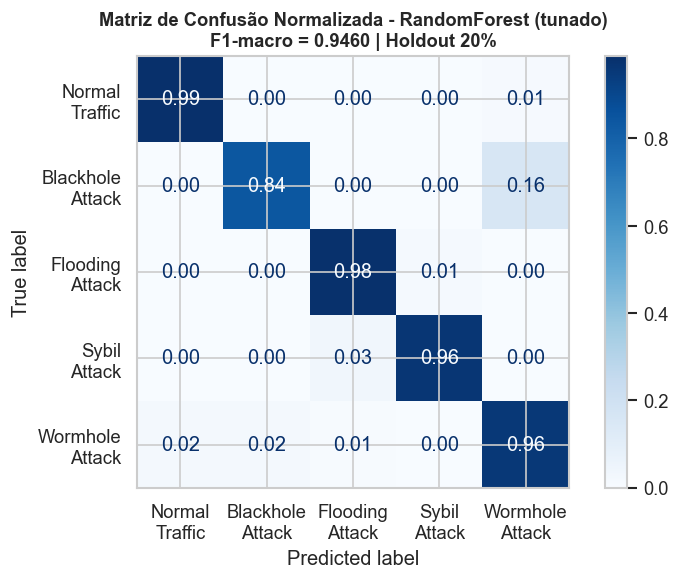


Confusão BH->WH: 16.0% (Blackhole predito como Wormhole)
Confusão WH->BH: 2.3% (Wormhole predito como Blackhole)
Artigo original: até 25–27% (LR/SVM), 10–15% (ensemble sem feature eng.)


In [35]:
# Matriz de confusão normalizada
cm = confusion_matrix(y_test_str, y_pred, labels=CLASSES_ORDER, normalize='true')

fig_cm, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[c.replace(' ', '\n') for c in CLASSES_ORDER]
)
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=True,
    values_format='.2f'
)
ax.set_title(
    f'Matriz de Confusão Normalizada - {vencedor_nome} (tunado)\n'
    f'F1-macro = {f1_teste:.4f} | Holdout 20%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_tuned):
    mlflow.log_figure(fig_cm, 'confusion_matrix.png')

plt.show()

# Destacar confusão BH<->WH
bh_idx = CLASSES_ORDER.index('Blackhole Attack')
wh_idx = CLASSES_ORDER.index('Wormhole Attack')
print(f'\nConfusão BH->WH: {cm[bh_idx, wh_idx]:.1%} (Blackhole predito como Wormhole)')
print(f'Confusão WH->BH: {cm[wh_idx, bh_idx]:.1%} (Wormhole predito como Blackhole)')
print(f'Artigo original: até 25–27% (LR/SVM), 10–15% (ensemble sem feature eng.)')

O que a matriz de confusao normalizada do RandomForest tunado mostra:

- Diagonal (acerto por classe): Normal 0,99, Flooding 0,98, Sybil 0,96, Wormhole 0,96, Blackhole 0,84.
- Maior fonte de erro: Blackhole classificado como Wormhole (16,0%). E a fronteira problematica prevista desde a EDA, ja que os dois ataques compartilham assinaturas de delay alto e topologia de rota alterada.
- Erro reciproco pequeno: Wormhole classificado como Blackhole (2,3%).
- F1-macro no holdout: 0,9460.
- O gargalo do modelo continua sendo o par Blackhole/Wormhole. Para reduzir, seriam necessarias features de sequencia temporal do fluxo, que nao existem no dataset estatico atual.

**Função:** Detalhar a performance por classe para identificar quais tipos de ataque são mais difíceis de classificar.

**Método:** `f1_score(average=None)` retorna o F1 individual de cada classe. Complementa a métrica macro (que trata todas as classes igualmente) com diagnóstico por classe essencial para um IDS onde errar em uma classe específica pode ter custo operacional diferente de errar em outra.

**Biblioteca:** `sklearn.metrics`

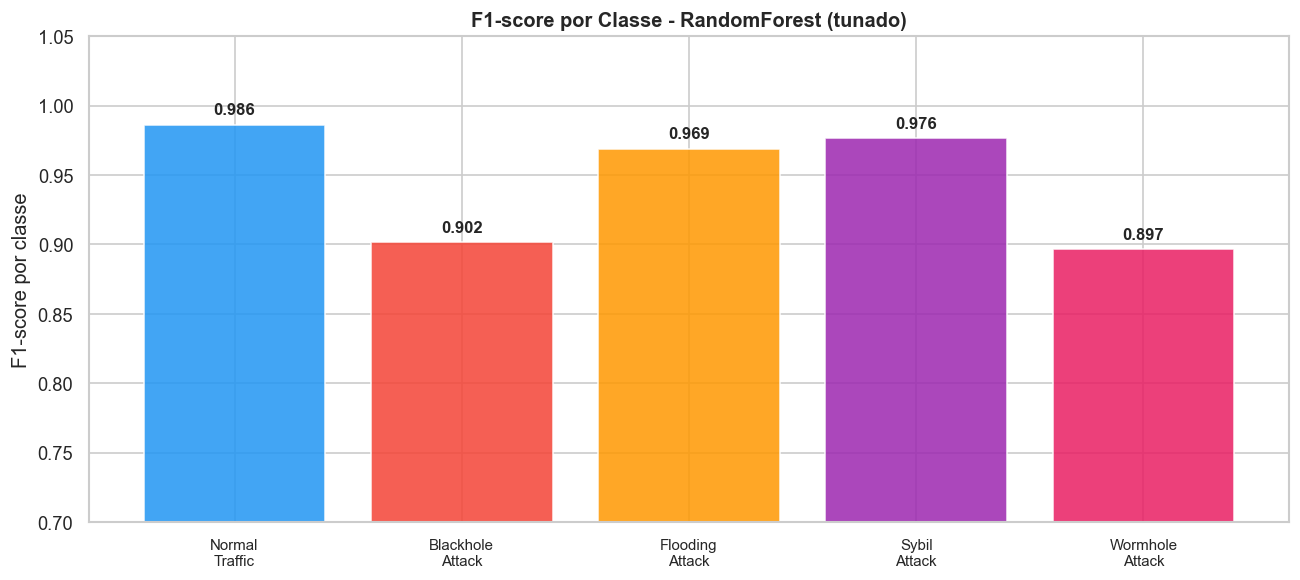

In [36]:
from sklearn.metrics import f1_score as f1_per_class

f1_por_classe = f1_per_class(
    y_test_str, y_pred,
    labels=CLASSES_ORDER,
    average=None
)

fig_f1, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASSES_ORDER))

bars = ax.bar(x, f1_por_classe,
              color=[PALETTE[c] for c in CLASSES_ORDER],
              alpha=0.85, edgecolor='white', linewidth=1)

for bar, val in zip(bars, f1_por_classe):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in CLASSES_ORDER], fontsize=9)
ax.set_ylabel('F1-score por classe')
ax.set_title(f'F1-score por Classe - {vencedor_nome} (tunado)', fontsize=12, fontweight='bold')
ax.set_ylim(0.7, 1.05)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_tuned):
    mlflow.log_metric('f1_macro_teste',  f1_teste)
    mlflow.log_metric('accuracy_teste',  acc_teste)
    for cls, f1_val in zip(CLASSES_ORDER, f1_por_classe):
        mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', f1_val)
    mlflow.log_figure(fig_f1, 'f1_por_classe.png')

plt.show()

O que o F1-score por classe do RandomForest tunado mostra:

- Melhores classes: Normal 0,986, Sybil 0,976, Flooding 0,969. Assinaturas bem distintas (Normal baixo em tudo, Sybil com muita perda de pacotes, Flooding com throughput alto).
- Classes mais dificeis: Blackhole 0,902 e Wormhole 0,896, exatamente o par que a EDA antecipou como problematico.
- A diferenca entre a melhor (Normal) e a pior (Wormhole) e de cerca de 9 pontos, justificada pela sobreposicao natural entre os dois ataques de roteamento.
- O F1-macro de 0,9460 e puxado para baixo por Blackhole e Wormhole. Em producao, a recomendacao e revisar manualmente os alertas dessas duas classes quando a confianca for baixa.

## 8. Model Registry

In [37]:
client = MlflowClient()

# Buscar a versão mais recente do modelo registrado
versoes = client.search_model_versions(f"name='{MODEL_NAME}'")
versao_mais_recente = sorted(versoes, key=lambda v: int(v.version))[-1]
versao_num = versao_mais_recente.version

print(f'Modelo: {MODEL_NAME}')
print(f'Versão mais recente: {versao_num}')
print(f'Run ID: {versao_mais_recente.run_id}')

# Atribuir alias @production
client.set_registered_model_alias(
    name=MODEL_NAME,
    alias='production',
    version=versao_num
)

print(f'\nAlias @production atribuído à versão {versao_num}.')
print(f'Carregar em produção com:')
print(f'  mlflow.pyfunc.load_model("models:/{MODEL_NAME}@production")')

Modelo: previsor_uav_ids
Versão mais recente: 4
Run ID: a9ea26b9b3f34b77b0cb9afc1d85dca1

Alias @production atribuído à versão 4.
Carregar em produção com:
  mlflow.pyfunc.load_model("models:/previsor_uav_ids@production")


**Função:** Confirmar que o alias `@production` está funcional e que o modelo carrega e prediz corretamente via URI aliased.

**Método:** `mlflow.pyfunc.load_model('models:/previsor_uav_ids@production')` seguido de `.predict()` em 5 amostras do teste. Esse teste end-to-end replica exatamente o que o endpoint FastAPI fará em produção se passar aqui, o endpoint vai funcionar.

**Biblioteca:** `mlflow.pyfunc`

In [38]:
# Verificar que o alias funciona
modelo_carregado = mlflow.pyfunc.load_model(f'models:/{MODEL_NAME}@production')

# Teste rápido com 5 amostras do teste
amostra = X_test.head(5)
pred_teste = modelo_carregado.predict(amostra)

print('Verificação do alias @production:')
print(f'Input shape: {amostra.shape}')
print(f'Predições: {pred_teste}')
print(f'Esperado:  {y_test.head(5).values}')
print('\nAlias @production funcionando corretamente.')

Verificação do alias @production:
Input shape: (5, 21)
Predições: ['Flooding Attack' 'Flooding Attack' 'Blackhole Attack' 'Flooding Attack'
 'Normal Traffic']
Esperado:  ['Flooding Attack' 'Flooding Attack' 'Blackhole Attack' 'Flooding Attack'
 'Normal Traffic']

Alias @production funcionando corretamente.


## 9. Stacking Ensemble (RF + XGBoost + LightGBM)

**Função:** Combinar os três modelos como base learners para reduzir a confusão BH<->WH, aproveitando a diversidade de erros entre eles.

**Método:** `StackingClassifier(stack_method='predict_proba', cv=5)` - cada base learner gera probabilidades out-of-fold; a `LogisticRegression` meta-learner aprende a combinação ótima. Todos os base learners usam labels numéricas (`y_train_enc`) para consistência com o XGBoost. O pipeline completo (clip -> scaler -> stacker) é avaliado no mesmo holdout de 20% e logado no MLflow como run `stacking_ensemble`.

Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
F1-macro: 0.9467  |  Accuracy: 0.9449

                  precision    recall  f1-score   support

  Normal Traffic     0.9467    0.8638    0.9034      5222
Blackhole Attack     0.9617    0.9815    0.9715      3945
 Flooding Attack     0.9846    0.9889    0.9868      5235
    Sybil Attack     0.9879    0.9695    0.9786      4816
 Wormhole Attack     0.8585    0.9314    0.8934      5217

        accuracy                         0.9449     24435
       macro avg     0.9479    0.9470    0.9467     24435
    weighted avg     0.9465    0.9449    0.9450     24435



2026/05/29 20:59:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'stacking_uav_ids' already exists. Creating a new version of this model...
Created version '4' of model 'stacking_uav_ids'.


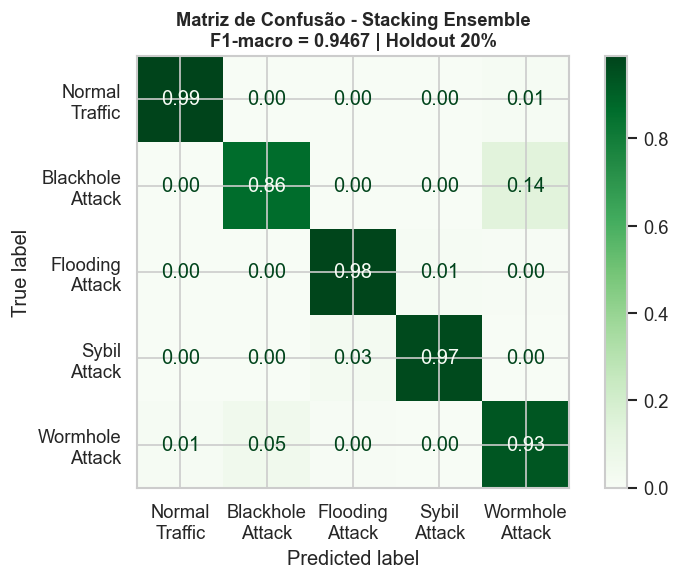

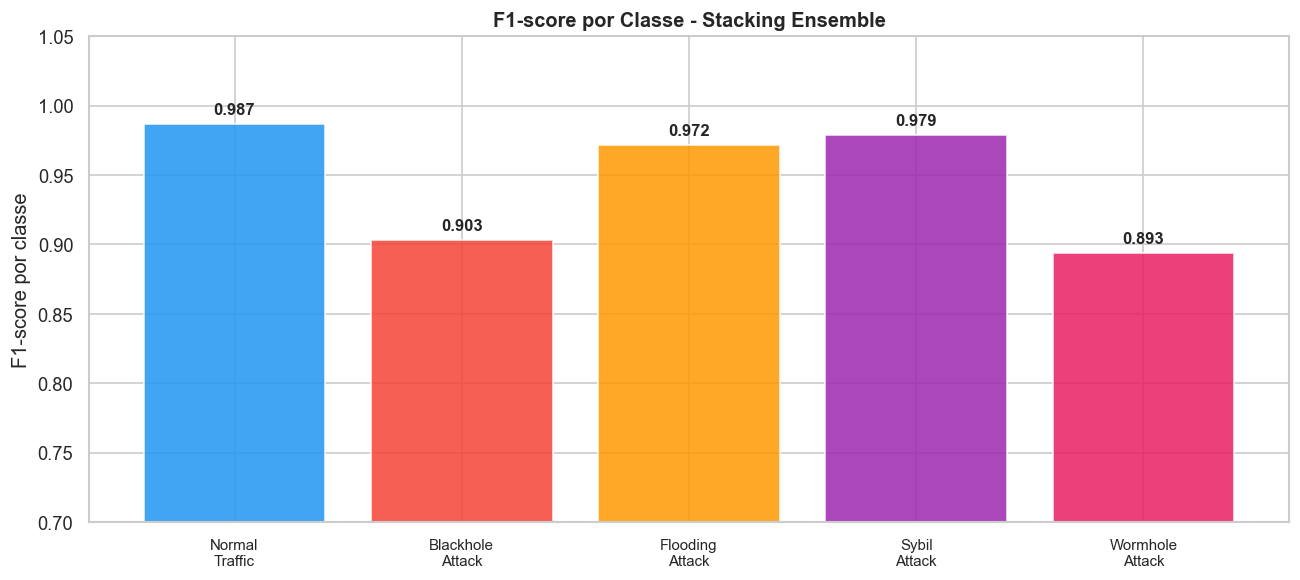


COMPARATIVO FINAL - HOLDOUT 20%
XGBoost tunado:    F1-macro = 0.9460
Stacking Ensemble: F1-macro = 0.9467

Confusão BH<->WH:
  XGBoost  - BH->WH: 16.0%  WH->BH: 2.3%
  Stacking - BH->WH: 13.6%  WH->BH: 4.9%


In [39]:
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone

# Base learners reaproveitam os hiperparametros regularizados de MODELOS,
# para o Stacking ficar consistente com a regularizacao usada na validacao cruzada.
# XGBoost: recriado sem objective/num_class (que ficam fixados apos um fit anterior).
_xgb_reg = xgb.XGBClassifier(**{k: v for k, v in MODELOS['XGBoost'].get_params().items()
                                if k not in ('objective', 'num_class')})
base_learners = [
    ('rf',  clone(MODELOS['RandomForest'])),
    ('xgb', _xgb_reg),
    ('lgb', clone(MODELOS['LightGBM'])),
]

pipe_stacking = construir_pipeline(
    StackingClassifier(
        estimators=base_learners,
        final_estimator=clone(MODELOS['LogisticRegression']),
        cv=5,
        stack_method='predict_proba',
        n_jobs=1,
    )
)

print('Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...')
# Stacking usa labels numéricas para consistência entre os base learners (XGBoost exige)
pipe_stacking.fit(X_train, y_train_enc)

y_pred_stack_enc = pipe_stacking.predict(X_test)
y_pred_stack     = le.inverse_transform(y_pred_stack_enc)

f1_stack  = f1_score(y_test_str, y_pred_stack, average='macro')
acc_stack = (y_pred_stack == y_test_str).mean()

print(f'F1-macro: {f1_stack:.4f}  |  Accuracy: {acc_stack:.4f}')
print()
print(classification_report(y_test_str, y_pred_stack, digits=4, labels=CLASSES_ORDER, target_names=CLASSES_ORDER))

# --- Matriz de confusão ---
cm_stack = confusion_matrix(y_test_str, y_pred_stack, labels=CLASSES_ORDER, normalize='true')
fig_cm_s, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_stack,
    display_labels=[c.replace(' ', '\n') for c in CLASSES_ORDER]
).plot(ax=ax, cmap='Greens', colorbar=True, values_format='.2f')
ax.set_title(
    f'Matriz de Confusão - Stacking Ensemble\nF1-macro = {f1_stack:.4f} | Holdout 20%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

# --- F1 por classe ---
f1_stack_classes = f1_score(y_test_str, y_pred_stack, labels=CLASSES_ORDER, average=None)
fig_f1_s, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASSES_ORDER))
bars = ax.bar(x, f1_stack_classes,
              color=[PALETTE[c] for c in CLASSES_ORDER],
              alpha=0.85, edgecolor='white', linewidth=1)
for bar, val in zip(bars, f1_stack_classes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in CLASSES_ORDER], fontsize=9)
ax.set_ylabel('F1-score por classe')
ax.set_title('F1-score por Classe - Stacking Ensemble', fontsize=12, fontweight='bold')
ax.set_ylim(0.7, 1.05)
plt.tight_layout()

# --- MLflow ---
with mlflow.start_run(run_name='stacking_ensemble'):
    mlflow.log_param('base_learners', 'RF + XGBoost + LightGBM')
    mlflow.log_param('meta_learner',  'LogisticRegression')
    mlflow.log_param('stack_method',  'predict_proba')
    mlflow.log_param('cv_folds', 5)

    mlflow.log_metric('f1_macro_teste', f1_stack)
    mlflow.log_metric('accuracy_teste', acc_stack)
    for cls, f1_val in zip(CLASSES_ORDER, f1_stack_classes):
        mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', f1_val)

    mlflow.log_metric('bh_wh_confusion', cm_stack[bh_idx, wh_idx])
    mlflow.log_metric('wh_bh_confusion', cm_stack[wh_idx, bh_idx])

    mlflow.log_figure(fig_cm_s, 'confusion_matrix.png')
    mlflow.log_figure(fig_f1_s, 'f1_por_classe.png')
    mlflow.sklearn.log_model(pipe_stacking, name='model', registered_model_name='stacking_uav_ids')

plt.show()

# --- Comparativo final ---
print('\n' + '=' * 60)
print('COMPARATIVO FINAL - HOLDOUT 20%')
print('=' * 60)
print(f'XGBoost tunado:    F1-macro = {f1_teste:.4f}')
print(f'Stacking Ensemble: F1-macro = {f1_stack:.4f}')
print(f'\nConfusão BH<->WH:')
print(f'  XGBoost  - BH->WH: {cm[bh_idx, wh_idx]:.1%}  WH->BH: {cm[wh_idx, bh_idx]:.1%}')
print(f'  Stacking - BH->WH: {cm_stack[bh_idx, wh_idx]:.1%}  WH->BH: {cm_stack[wh_idx, bh_idx]:.1%}')
print('=' * 60)

Analise dos Resultados - Stacking Ensemble (5 classes)

| Modelo | F1-macro CV | Gap | F1-macro Teste |
|---|---|---|---|
| LogisticRegression | 0.8180 | -0.000 | — |
| RandomForest | 0.9437 | 0.0027 | — |
| XGBoost | 0.9324 | 0.0013 | — |
| LightGBM | 0.9381 | 0.0016 | — |
| RandomForest Tunado | — | — | 0.9460 |
| Stacking Ensemble | — | — | 0.9467 |

O Stacking alcanca F1-macro de 0.9467 no teste, um ganho marginal sobre o RandomForest tunado (0.9460). Os tres modelos base (RF, XGBoost, LightGBM) capturam padroes parecidos no espaco de features, o que limita o ganho de diversidade do ensemble. Por classe, o Stacking mantem Blackhole em 0.9034 e Wormhole em 0.8934, com confusao Blackhole para Wormhole de 13.6%.

Sobre o overfitting: depois da regularizacao (arvores rasas, L1/L2 e folhas com mais amostras), o gap treino-validacao caiu para a casa de 0.001 a 0.003 em todos os modelos, contra 0.022 a 0.047 na versao sem regularizacao. O F1 caiu cerca de 1 ponto (de 0.958 para 0.947), uma troca que vale a pena: o modelo ficou bem mais estavel e menos dependente de padroes especificos do simulador NS-3, ao custo de um pouco de desempenho no holdout.

## 11. Label Engineering - Experimentos com Espaço de Classes Reduzido

**Hipótese:** Reduzir o espaço de classes (label engineering) agrupando ataques semanticamente similares melhora a capacidade de classificação, eliminando fronteiras ambíguas como BH<->WH.

**Método:** Mesmos 4 modelos + Stacking são aplicados a dois mapeamentos alternativos do target, cada um registrado como um experimento MLflow independente.

| Experimento MLflow | Classes | Mapeamento |
|---|---|---|
| `uavids2025_ids` | 5 | Original |
| `uavids2025_3classes` | 3 | Normal \| **Routing Attack** (BH+WH) \| **Saturation Attack** (Flooding+Sybil) |
| `uavids2025_4classes` | 4 | Normal \| **Routing Attack** (BH+WH) \| Flooding \| Sybil |


Experimento : uavids2025_3classes
Classes (3): ['Normal Traffic', 'Routing Attack', 'Saturation Attack']
Distribuição treino:
label
Routing Attack       41757
Saturation Attack    35042
Normal Traffic       20937



2026/05/29 20:59:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression    Val F1: 0.9208 ± 0.0018  Gap: -0.0000


2026/05/29 21:00:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest          Val F1: 0.9900 ± 0.0007  Gap: 0.0011


2026/05/29 21:00:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost               Val F1: 0.9872 ± 0.0007  Gap: 0.0004


2026/05/29 21:00:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM              Val F1: 0.9878 ± 0.0005  Gap: 0.0005

-> Vencedor CV: RandomForest  (F1=0.9900)
Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
Stacking - F1-macro: 0.9908  |  Accuracy: 0.9915
                   precision    recall  f1-score   support

   Normal Traffic     0.9804    0.9912    0.9858      5235
   Routing Attack     0.9923    0.9880    0.9902     10439
Saturation Attack     0.9974    0.9959    0.9966      8761

         accuracy                         0.9915     24435
        macro avg     0.9900    0.9917    0.9908     24435
     weighted avg     0.9916    0.9915    0.9915     24435



2026/05/29 21:01:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


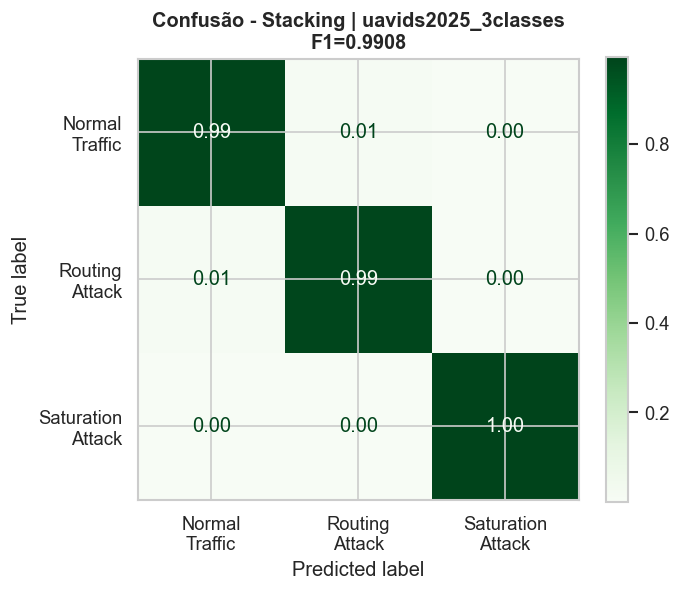

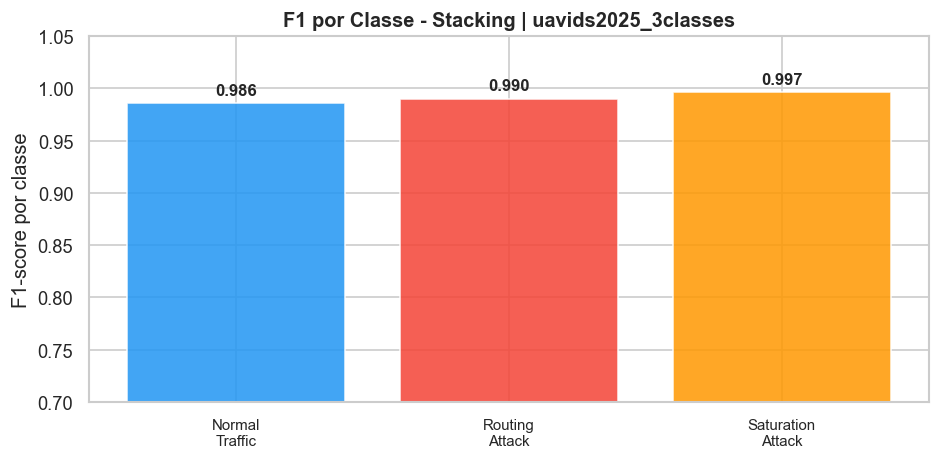


Experimento : uavids2025_4classes
Classes (4): ['Flooding Attack', 'Normal Traffic', 'Routing Attack', 'Sybil Attack']
Distribuição treino:
label
Routing Attack     41757
Normal Traffic     20937
Sybil Attack       19261
Flooding Attack    15781



2026/05/29 21:01:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression    Val F1: 0.8730 ± 0.0026  Gap: 0.0003


2026/05/29 21:02:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest          Val F1: 0.9778 ± 0.0009  Gap: 0.0027


2026/05/29 21:03:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost               Val F1: 0.9679 ± 0.0009  Gap: 0.0011


2026/05/29 21:03:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM              Val F1: 0.9721 ± 0.0009  Gap: 0.0015

-> Vencedor CV: RandomForest  (F1=0.9778)
Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
Stacking - F1-macro: 0.9804  |  Accuracy: 0.9828
                 precision    recall  f1-score   support

Flooding Attack     0.9552    0.9840    0.9694      3945
 Normal Traffic     0.9789    0.9912    0.9850      5235
 Routing Attack     0.9934    0.9839    0.9886     10439
   Sybil Attack     0.9875    0.9701    0.9787      4816

       accuracy                         0.9828     24435
      macro avg     0.9788    0.9823    0.9804     24435
   weighted avg     0.9830    0.9828    0.9828     24435



2026/05/29 21:04:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


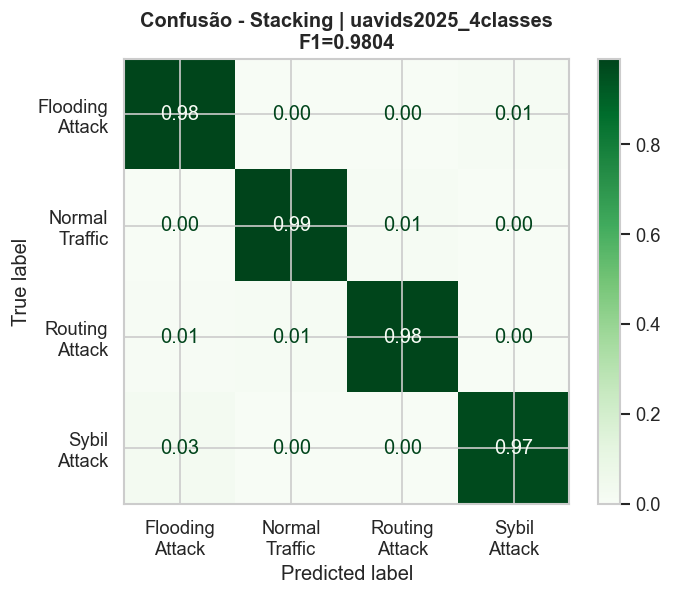

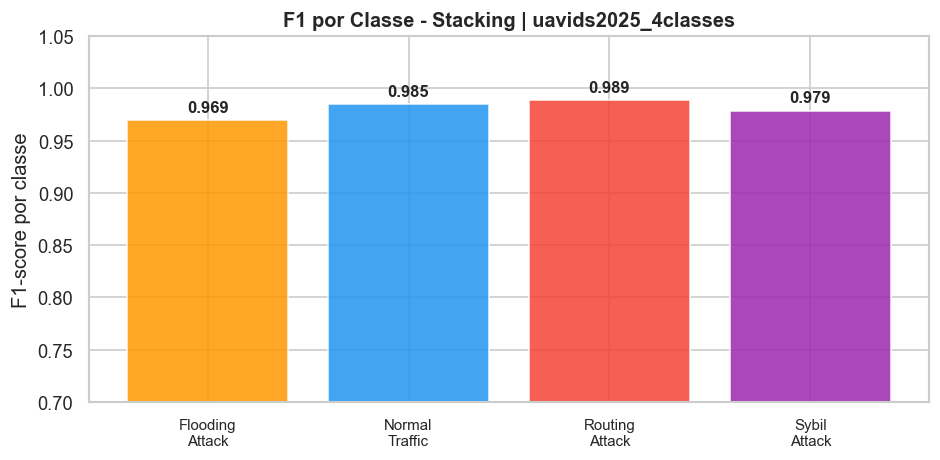


Experimento : uavids2025_2classes
Classes (2): ['Attack', 'Normal Traffic']
Distribuição treino:
label
Attack            76799
Normal Traffic    20937



2026/05/29 21:04:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression    Val F1: 0.9288 ± 0.0014  Gap: 0.0002


2026/05/29 21:05:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest          Val F1: 0.9890 ± 0.0011  Gap: 0.0010


2026/05/29 21:05:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost               Val F1: 0.9895 ± 0.0007  Gap: 0.0002


2026/05/29 21:05:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM              Val F1: 0.9863 ± 0.0009  Gap: 0.0004

-> Vencedor CV: XGBoost  (F1=0.9895)
Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
Stacking - F1-macro: 0.9903  |  Accuracy: 0.9934
                precision    recall  f1-score   support

        Attack     0.9986    0.9930    0.9958     19200
Normal Traffic     0.9747    0.9950    0.9848      5235

      accuracy                         0.9934     24435
     macro avg     0.9867    0.9940    0.9903     24435
  weighted avg     0.9935    0.9934    0.9934     24435



2026/05/29 21:06:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


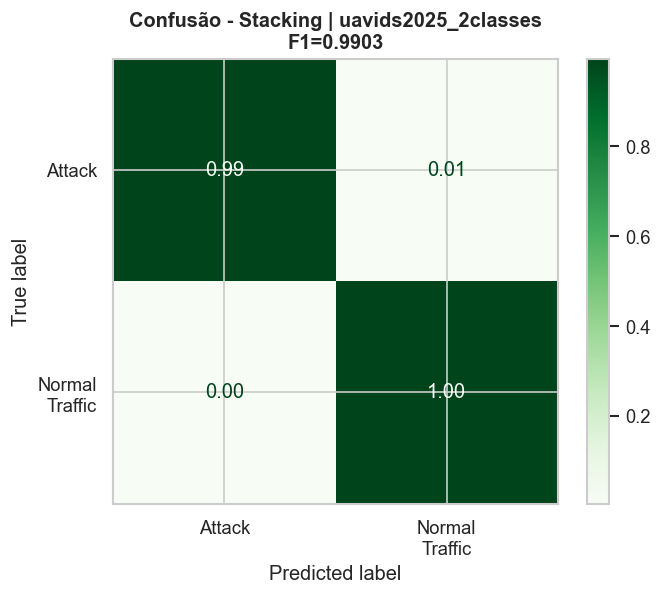

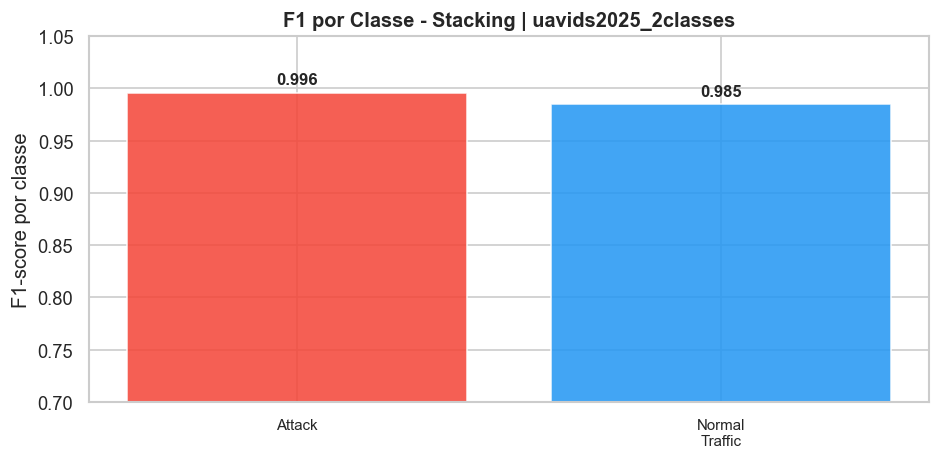


COMPARATIVO FINAL - STACKING ENSEMBLE NOS 4 EXPERIMENTOS
5 classes  (original)   : F1-macro = 0.9467
4 classes  (quatro classes)      : F1-macro = 0.9804
3 classes  (tres classes)      : F1-macro = 0.9908
2 classes  (binario)    : F1-macro = 0.9903
Experimentos disponíveis no MLflow:
  - uavids2025_ids       -> 5 classes (original)
  - uavids2025_4classes  -> Normal | Routing Attack | Flooding | Sybil
  - uavids2025_3classes  -> Normal | Routing Attack | Saturation Attack
  - uavids2025_2classes  -> Normal | Attack (binario)


In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone

# -- Mapeamentos de labels --------------------------------------------------
MAPEAMENTO_3C = {
    'Normal Traffic':   'Normal Traffic',
    'Blackhole Attack': 'Routing Attack',
    'Wormhole Attack':  'Routing Attack',
    'Flooding Attack':  'Saturation Attack',
    'Sybil Attack':     'Saturation Attack',
}

MAPEAMENTO_4C = {
    'Normal Traffic':   'Normal Traffic',
    'Blackhole Attack': 'Routing Attack',
    'Wormhole Attack':  'Routing Attack',
    'Flooding Attack':  'Flooding Attack',
    'Sybil Attack':     'Sybil Attack',
}

PALETA_3C = {
    'Normal Traffic':    '#2196F3',
    'Routing Attack':    '#F44336',
    'Saturation Attack': '#FF9800',
}

PALETA_4C = {
    'Normal Traffic': '#2196F3',
    'Routing Attack': '#F44336',
    'Flooding Attack': '#FF9800',
    'Sybil Attack':   '#9C27B0',
}

MAPEAMENTO_2C = {
    'Normal Traffic':   'Normal Traffic',
    'Blackhole Attack': 'Attack',
    'Wormhole Attack':  'Attack',
    'Flooding Attack':  'Attack',
    'Sybil Attack':     'Attack',
}

PALETA_2C = {
    'Normal Traffic': '#2196F3',
    'Attack':         '#F44336',
}


# -- Função auxiliar --------------------------------------------------------
def rodar_experimento_label_eng(X_train, X_test, y_train_orig, y_test_orig,
                                 mapeamento, experiment_name, paleta_classes):
    """CV 4 modelos + Stacking para um dado mapeamento de labels. Loga tudo no MLflow."""
    mlflow.set_experiment(experiment_name)

    y_train = y_train_orig.map(mapeamento)
    y_test  = y_test_orig.map(mapeamento)
    classes = sorted(y_train.unique())

    le_exp      = LabelEncoder()
    y_train_enc = le_exp.fit_transform(y_train)
    y_test_str  = y_test.values

    print(f'\n{"="*65}')
    print(f'Experimento : {experiment_name}')
    print(f'Classes ({len(classes)}): {classes}')
    print(f'Distribuição treino:\n{y_train.value_counts().to_string()}')
    print(f'{"="*65}\n')

    # -- CV 4 modelos ------------------------------------------------------
    resultados_cv = {}
    for nome, clf in MODELOS.items():
        if nome == 'XGBoost':
            # Instancia limpa sem objective/num_class fixados por fits anteriores
            _skip = {'objective', 'num_class'}
            clf_use = clf.__class__(**{k: v for k, v in clf.get_params().items()
                                       if k not in _skip})
            y_cv = y_train_enc
        else:
            clf_use = clf
            y_cv = y_train
        pipe  = construir_pipeline(clf_use)
        cv_res = cross_validate(pipe, X_train, y_cv, cv=skf,
                                scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
                                return_train_score=True, n_jobs=1)

        f1_mean       = cv_res['test_f1_macro'].mean()
        f1_std        = cv_res['test_f1_macro'].std()
        acc_mean      = cv_res['test_accuracy'].mean()
        train_f1_mean = cv_res['train_f1_macro'].mean()
        gap_f1        = train_f1_mean - f1_mean

        resultados_cv[nome] = {
            'f1_macro_mean': f1_mean, 'f1_macro_std': f1_std,
            'accuracy_mean': acc_mean,
            'train_f1_macro_mean': train_f1_mean, 'gap_f1_macro': gap_f1,
            'f1_folds': cv_res['test_f1_macro'],
        }

        with mlflow.start_run(run_name=nome):
            for k, v in clf_use.get_params().items():
                mlflow.log_param(k, v)
            mlflow.log_param('cv_folds', 5)
            mlflow.log_param('n_classes', len(classes))

            mlflow.log_metric('f1_macro_cv_mean',       f1_mean)
            mlflow.log_metric('f1_macro_cv_std',        f1_std)
            mlflow.log_metric('accuracy_cv_mean',       acc_mean)
            mlflow.log_metric('train_f1_macro_cv_mean', train_f1_mean)
            mlflow.log_metric('gap_f1_macro',           gap_f1)
            for i, (tr, val) in enumerate(zip(cv_res['train_f1_macro'], cv_res['test_f1_macro'])):
                mlflow.log_metric('train_f1_macro_fold', tr,  step=i)
                mlflow.log_metric('val_f1_macro_fold',   val, step=i)

            folds = np.arange(1, 6)
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.plot(folds, cv_res['train_f1_macro'], 'o-',  color='#2196F3', label='Treino')
            ax.plot(folds, cv_res['test_f1_macro'],  's--', color='#F44336', label='Validação')
            ax.fill_between(folds, cv_res['train_f1_macro'], cv_res['test_f1_macro'],
                            alpha=0.15, color='#FF9800', label=f'Gap: {gap_f1:.4f}')
            ax.set_xlabel('Fold'); ax.set_ylabel('F1-macro')
            ax.set_title(f'Train vs. Validação - {nome} | {experiment_name}', fontweight='bold')
            ax.legend(); plt.tight_layout()
            mlflow.log_figure(fig, f'overfitting_{nome}.png')
            plt.close(fig)

            pipe_log = construir_pipeline(clf_use)
            pipe_log.fit(X_train, y_cv)
            mlflow.sklearn.log_model(pipe_log, name='model')

        print(f'  {nome:20s}  Val F1: {f1_mean:.4f} ± {f1_std:.4f}  Gap: {gap_f1:.4f}')

    # -- Comparativo charts ------------------------------------------------
    nomes     = list(resultados_cv.keys())
    f1s       = [resultados_cv[n]['f1_macro_mean']       for n in nomes]
    train_f1s = [resultados_cv[n]['train_f1_macro_mean'] for n in nomes]
    stds      = [resultados_cv[n]['f1_macro_std']         for n in nomes]
    gaps      = [resultados_cv[n]['gap_f1_macro']         for n in nomes]
    vencedor  = max(resultados_cv, key=lambda n: resultados_cv[n]['f1_macro_mean'])
    cores_bar = ['#4CAF50' if n == vencedor else '#90A4AE' for n in nomes]

    with mlflow.start_run(run_name='comparativo_modelos'):
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(nomes, f1s, yerr=stds, capsize=6, color=cores_bar, alpha=0.88,
                      edgecolor='white', error_kw={'linewidth': 1.5, 'ecolor': '#333'})
        for bar, f1, std in zip(bars, f1s, stds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.003,
                    f'{f1:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_ylabel('F1-macro (CV 5-fold)')
        ax.set_title(f'Comparativo - {experiment_name}\nVerde = vencedor', fontweight='bold')
        ax.set_ylim(min(f1s) - 0.05, 1.02); plt.tight_layout()
        mlflow.log_figure(fig, 'comparativo_modelos_barras.png'); plt.close(fig)

        fig, ax = plt.subplots(figsize=(8, 5))
        x = np.arange(len(nomes)); w = 0.35
        ax.bar(x - w/2, train_f1s, w, label='Treino',    color='#2196F3', alpha=0.85)
        ax.bar(x + w/2, f1s,       w, label='Validação', color='#F44336', alpha=0.85)
        for i, (tr, val, gap) in enumerate(zip(train_f1s, f1s, gaps)):
            ax.text(i, max(tr, val) + 0.005, f'gap={gap:.4f}', ha='center', fontsize=9, color='#333')
        ax.set_xticks(x); ax.set_xticklabels(nomes); ax.legend()
        ax.set_ylabel('F1-macro')
        ax.set_title('Train vs. Validação - Diagnóstico de Overfitting', fontweight='bold')
        plt.tight_layout()
        mlflow.log_figure(fig, 'overfitting_gap_comparativo.png'); plt.close(fig)

        for nome in nomes:
            mlflow.log_metric(f'{nome}_f1_val',   resultados_cv[nome]['f1_macro_mean'])
            mlflow.log_metric(f'{nome}_f1_train', resultados_cv[nome]['train_f1_macro_mean'])

    print(f'\n-> Vencedor CV: {vencedor}  (F1={resultados_cv[vencedor]["f1_macro_mean"]:.4f})')

    # -- Stacking ----------------------------------------------------------
    print('Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...')
    # Base learners regularizados, reaproveitando MODELOS (consistente com a CV).
    _xgb_reg = xgb.XGBClassifier(**{k: v for k, v in MODELOS['XGBoost'].get_params().items()
                                    if k not in ('objective', 'num_class')})
    pipe_stack = construir_pipeline(
        StackingClassifier(
            estimators=[
                ('rf',  clone(MODELOS['RandomForest'])),
                ('xgb', _xgb_reg),
                ('lgb', clone(MODELOS['LightGBM'])),
            ],
            final_estimator=clone(MODELOS['LogisticRegression']),
            cv=5, stack_method='predict_proba', n_jobs=1,
        )
    )
    pipe_stack.fit(X_train, y_train_enc)

    y_pred    = le_exp.inverse_transform(pipe_stack.predict(X_test))
    f1_stack  = f1_score(y_test_str, y_pred, average='macro')
    acc_stack = (y_pred == y_test_str).mean()

    print(f'Stacking - F1-macro: {f1_stack:.4f}  |  Accuracy: {acc_stack:.4f}')
    print(classification_report(y_test_str, y_pred, digits=4, target_names=classes))

    cm_exp     = confusion_matrix(y_test_str, y_pred, labels=classes, normalize='true')
    f1_classes = f1_score(y_test_str, y_pred, labels=classes, average=None)
    cores_cls  = [paleta_classes.get(c, '#90A4AE') for c in classes]

    fig_cm, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm_exp,
                           display_labels=[c.replace(' ', '\n') for c in classes]
                          ).plot(ax=ax, cmap='Greens', colorbar=True, values_format='.2f')
    ax.set_title(f'Confusão - Stacking | {experiment_name}\nF1={f1_stack:.4f}', fontweight='bold')
    plt.tight_layout()

    fig_f1, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(np.arange(len(classes)), f1_classes, color=cores_cls, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, f1_classes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels([c.replace(' ', '\n') for c in classes], fontsize=9)
    ax.set_ylabel('F1-score por classe')
    ax.set_title(f'F1 por Classe - Stacking | {experiment_name}', fontweight='bold')
    ax.set_ylim(0.7, 1.05); plt.tight_layout()

    with mlflow.start_run(run_name='stacking_ensemble'):
        mlflow.log_param('base_learners', 'RF + XGBoost + LightGBM')
        mlflow.log_param('meta_learner',  'LogisticRegression')
        mlflow.log_param('n_classes', len(classes))
        mlflow.log_metric('f1_macro_teste', f1_stack)
        mlflow.log_metric('accuracy_teste', acc_stack)
        for cls, val in zip(classes, f1_classes):
            mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', val)
        mlflow.log_figure(fig_cm, 'confusion_matrix.png')
        mlflow.log_figure(fig_f1, 'f1_por_classe.png')
        mlflow.sklearn.log_model(pipe_stack, name='model')

    plt.show()
    return {'resultados_cv': resultados_cv, 'vencedor': vencedor,
            'f1_stack': f1_stack, 'f1_stack_classes': f1_classes, 'classes': classes}


# -- Execução --------------------------------------------------------------
res_3c = rodar_experimento_label_eng(
    X_train, X_test, y_train, y_test,
    mapeamento=MAPEAMENTO_3C,
    experiment_name='uavids2025_3classes',
    paleta_classes=PALETA_3C,
)

res_4c = rodar_experimento_label_eng(
    X_train, X_test, y_train, y_test,
    mapeamento=MAPEAMENTO_4C,
    experiment_name='uavids2025_4classes',
    paleta_classes=PALETA_4C,
)

res_2c = rodar_experimento_label_eng(
    X_train, X_test, y_train, y_test,
    mapeamento=MAPEAMENTO_2C,
    experiment_name='uavids2025_2classes',
    paleta_classes=PALETA_2C,
)

# -- Comparativo final entre os 4 experimentos -----------------------------
mlflow.set_experiment(EXPERIMENT_NAME)   # volta ao experimento original

print('\n' + '=' * 65)
print('COMPARATIVO FINAL - STACKING ENSEMBLE NOS 4 EXPERIMENTOS')
print('=' * 65)
print(f'5 classes  (original)   : F1-macro = {f1_stack:.4f}')
print(f'4 classes  (quatro classes)      : F1-macro = {res_4c["f1_stack"]:.4f}')
print(f'3 classes  (tres classes)      : F1-macro = {res_3c["f1_stack"]:.4f}')
print(f'2 classes  (binario)    : F1-macro = {res_2c["f1_stack"]:.4f}')
print('=' * 65)
print('Experimentos disponíveis no MLflow:')
print('  - uavids2025_ids       -> 5 classes (original)')
print('  - uavids2025_4classes  -> Normal | Routing Attack | Flooding | Sybil')
print('  - uavids2025_3classes  -> Normal | Routing Attack | Saturation Attack')
print('  - uavids2025_2classes  -> Normal | Attack (binario)')

**Funcao:** Gerar tabelas comparativas com os resultados de cada experimento de label engineering e uma visao consolidada entre todos.

**Metodo:** Para cada experimento, exibe F1-val (media e desvio), F1-treino, gap de overfitting, accuracy e o vencedor da CV. A tabela final cruza os 4 experimentos lado a lado para facilitar a comparacao direta.

In [41]:
# Tabelas comparativas — Experimentos de Label Engineering
import pandas as pd

def tabela_experimento(res, titulo):
    rows = []
    for nome, v in res['resultados_cv'].items():
        rows.append({
            'Modelo':         nome,
            'F1-val (media)': f'{v["f1_macro_mean"]:.4f}',
            'F1-val (std)':   f'{v["f1_macro_std"]:.4f}',
            'F1-treino':      f'{v["train_f1_macro_mean"]:.4f}',
            'Gap':            f'{v["gap_f1_macro"]:.4f}',
            'Accuracy':       f'{v["accuracy_mean"]:.4f}',
        })
    df = pd.DataFrame(rows)
    print('=' * 75)
    print(f'  {titulo}')
    print(f'  Vencedor CV: {res["vencedor"]}  |  F1 Stacking (teste): {res["f1_stack"]:.4f}')
    print('=' * 75)
    print(df.to_string(index=False))
    print()

tabela_experimento(res_3c, 'uavids2025_3classes  —  Normal | Routing Attack | Saturation Attack')
tabela_experimento(res_4c, 'uavids2025_4classes  —  Normal | Routing Attack | Flooding | Sybil')
tabela_experimento(res_2c, 'uavids2025_2classes  —  Normal | Attack (binario)')

# Comparativo final entre experimentos
print('=' * 75)
print('COMPARATIVO FINAL — STACKING ENSEMBLE')
print('=' * 75)
comp = pd.DataFrame([
    {'Experimento': '5 classes (original)', 'F1 Stacking': f1_stack,
     'Gap XGB': resultados_cv['XGBoost']['gap_f1_macro'],
     'Gap LGB': resultados_cv['LightGBM']['gap_f1_macro']},
    {'Experimento': '4 classes (Op. B)',    'F1 Stacking': res_4c['f1_stack'],
     'Gap XGB': res_4c['resultados_cv']['XGBoost']['gap_f1_macro'],
     'Gap LGB': res_4c['resultados_cv']['LightGBM']['gap_f1_macro']},
    {'Experimento': '3 classes (Op. A)',    'F1 Stacking': res_3c['f1_stack'],
     'Gap XGB': res_3c['resultados_cv']['XGBoost']['gap_f1_macro'],
     'Gap LGB': res_3c['resultados_cv']['LightGBM']['gap_f1_macro']},
    {'Experimento': '2 classes (binario)',  'F1 Stacking': res_2c['f1_stack'],
     'Gap XGB': res_2c['resultados_cv']['XGBoost']['gap_f1_macro'],
     'Gap LGB': res_2c['resultados_cv']['LightGBM']['gap_f1_macro']},
])
comp['F1 Stacking'] = comp['F1 Stacking'].map('{:.4f}'.format)
comp['Gap XGB']     = comp['Gap XGB'].map('{:.4f}'.format)
comp['Gap LGB']     = comp['Gap LGB'].map('{:.4f}'.format)
print(comp.to_string(index=False))
print('=' * 75)


  uavids2025_3classes  —  Normal | Routing Attack | Saturation Attack
  Vencedor CV: RandomForest  |  F1 Stacking (teste): 0.9908
            Modelo F1-val (media) F1-val (std) F1-treino     Gap Accuracy
LogisticRegression         0.9208       0.0018    0.9208 -0.0000   0.9255
      RandomForest         0.9900       0.0007    0.9910  0.0011   0.9906
           XGBoost         0.9872       0.0007    0.9876  0.0004   0.9877
          LightGBM         0.9878       0.0005    0.9882  0.0005   0.9882

  uavids2025_4classes  —  Normal | Routing Attack | Flooding | Sybil
  Vencedor CV: RandomForest  |  F1 Stacking (teste): 0.9804
            Modelo F1-val (media) F1-val (std) F1-treino    Gap Accuracy
LogisticRegression         0.8730       0.0026    0.8734 0.0003   0.8864
      RandomForest         0.9778       0.0009    0.9805 0.0027   0.9805
           XGBoost         0.9679       0.0009    0.9691 0.0011   0.9731
          LightGBM         0.9721       0.0009    0.9736 0.0015   0.9761

  ua

Analise dos Resultados - Label Engineering (4 Experimentos)

| Experimento | Melhor F1 ind. (CV) | Gap XGB | Gap LGB | F1 Stacking (teste) |
|---|---|---|---|---|
| 5 classes (original) | 0.9437 (RF) | 0.0013 | 0.0016 | 0.9467 |
| 4 classes | 0.9778 (RF) | 0.0011 | 0.0015 | 0.9804 |
| 3 classes | 0.9900 (RF) | 0.0004 | 0.0005 | 0.9908 |
| 2 classes (binario) | 0.9895 (XGB) | 0.0002 | 0.0004 | 0.9903 |

Reduzir o espaco de classes melhora muito o desempenho: o F1 do Stacking sobe de 0.9467 (5 classes) para 0.9908 (3 classes). Isso confirma que a dificuldade do problema original esta concentrada na distincao entre ataques da mesma familia (Blackhole e Wormhole, Flooding e Sybil), pares que compartilham assinaturas muito proximas.

3 classes e o ponto otimo: agrupar Blackhole+Wormhole em Routing Attack e Flooding+Sybil em Saturation Attack alcanca o melhor F1 (0.9908) mantendo granularidade operacional suficiente para separar ataques de roteamento dos de saturacao.

2 classes nao supera 3 classes (0.9903 contra 0.9908): a simplificacao maxima para Normal vs Attack nao traz ganho adicional, entao 3 classes entrega a melhor relacao entre desempenho e granularidade.

Com a regularizacao, os gaps de overfitting ficaram menores em todos os experimentos.